In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

data = {
    "Rainfall_mm": np.random.randint(500, 1501, 200),
    "Temperature_C": np.random.uniform(20, 35, 200),
    "Humidity_percent": np.random.uniform(50, 90, 200),
    "Fertilizer_kg": np.random.randint(50, 251, 200),
    "Area_hectare": np.random.uniform(1, 10, 200)
}

df = pd.DataFrame(data)

df["Yield_tons"] = (
    0.002 * df["Rainfall_mm"]
    + 0.05 * df["Temperature_C"]
    + 0.03 * df["Humidity_percent"]
    + 0.01 * df["Fertilizer_kg"]
    + 0.5 * df["Area_hectare"]
    + np.random.normal(0, 0.5, 200)
)

df.head()

,Rainfall_mm,Temperature_C,Humidity_percent,Fertilizer_kg,Area_hectare,Yield_tons
0,602,30.432741,55.534124,206,5.605097,9.131338
1,935,22.089972,55.309817,190,5.789021,9.291942
2,1360,29.066261,88.781475,95,1.964548,7.420588
3,770,28.097616,78.583804,84,5.026711,8.628603
4,606,23.045918,51.642701,183,5.793555,8.524887


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (200, 6)

Column Names:
Index(['Rainfall_mm', 'Temperature_C', 'Humidity_percent', 'Fertilizer_kg',
       'Area_hectare', 'Yield_tons'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rainfall_mm       200 non-null    int64  
 1   Temperature_C     200 non-null    float64
 2   Humidity_percent  200 non-null    float64
 3   Fertilizer_kg     200 non-null    int64  
 4   Area_hectare      200 non-null    float64
 5   Yield_tons        200 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 9.5 KB
None

Missing Values:
Rainfall_mm         0
Temperature_C       0
Humidity_percent    0
Fertilizer_kg       0
Area_hectare        0
Yield_tons          0
dtype: int64


In [ ]:
X = df[
    [
        "Rainfall_mm",
        "Temperature_C",
        "Humidity_percent",
        "Fertilizer_kg",
        "Area_hectare"
    ]
]

y = df["Yield_tons"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Rainfall_mm  Temperature_C  Humidity_percent  Fertilizer_kg  Area_hectare
0          602      30.432741         55.534124            206      5.605097
1          935      22.089972         55.309817            190      5.789021
2         1360      29.066261         88.781475             95      1.964548
3          770      28.097616         78.583804             84      5.026711
4          606      23.045918         51.642701            183      5.793555

Target (y):
0    9.131338
1    9.291942
2    7.420588
3    8.628603
4    8.524887
Name: Yield_tons, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully! 🌾")

Random Forest model trained successfully! 🌾


In [ ]:
y_pred = model.predict(X_test)

print("Predictions completed! 🌾")
print("\nFirst 10 predicted values:")
print(y_pred[:10])

Predictions completed! 🌾

First 10 predicted values:
[11.25079071 10.36244164 10.43293637  8.93334817  8.28192166  9.43408954
  7.82750059  9.97331732 11.15993272  8.87566095]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation
-------------------------
Mean Absolute Error (MAE): 0.6483993835248537
Mean Squared Error (MSE): 0.6762865673660446
Root Mean Squared Error (RMSE): 0.8223664434824932
R² Score: 0.7440836136931253


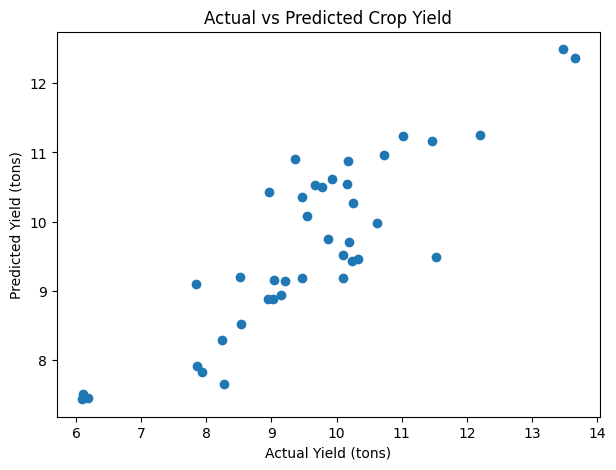

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield (tons)")
plt.ylabel("Predicted Yield (tons)")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

            Feature  Importance
4      Area_hectare    0.713382
3     Fertilizer_kg    0.125108
0       Rainfall_mm    0.085661
1     Temperature_C    0.046699
2  Humidity_percent    0.029149


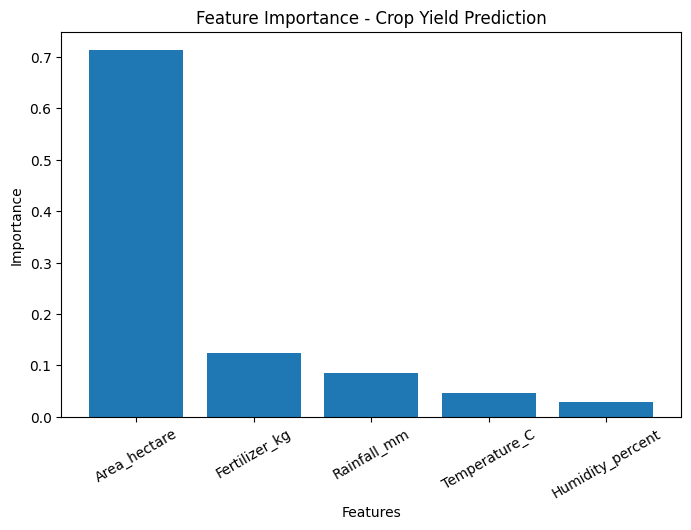

In [ ]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Crop Yield Prediction")

plt.xticks(rotation=30)
plt.show()

In [ ]:
new_crop = pd.DataFrame({
    "Rainfall_mm": [1200],
    "Temperature_C": [28],
    "Humidity_percent": [75],
    "Fertilizer_kg": [150],
    "Area_hectare": [5]
})

predicted_yield = model.predict(new_crop)

print("🌾 Crop Yield Prediction")
print("-------------------------")
print("Rainfall:", new_crop["Rainfall_mm"].iloc[0], "mm")
print("Temperature:", new_crop["Temperature_C"].iloc[0], "°C")
print("Humidity:", new_crop["Humidity_percent"].iloc[0], "%")
print("Fertilizer:", new_crop["Fertilizer_kg"].iloc[0], "kg")
print("Area:", new_crop["Area_hectare"].iloc[0], "hectares")
print()
print("Predicted Yield:", round(predicted_yield[0], 2), "tons")

🌾 Crop Yield Prediction
-------------------------
Rainfall: 1200 mm
Temperature: 28 °C
Humidity: 75 %
Fertilizer: 150 kg
Area: 5 hectares

Predicted Yield: 9.72 tons


In [ ]:
import joblib

joblib.dump(model, "crop_yield_random_forest.pkl")

print("Crop Yield model saved successfully! 🌾")

Crop Yield model saved successfully! 🌾


In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def predict_yield(rainfall, temperature, humidity, fertilizer, area):

    new_crop = pd.DataFrame({
        "Rainfall_mm": [rainfall],
        "Temperature_C": [temperature],
        "Humidity_percent": [humidity],
        "Fertilizer_kg": [fertilizer],
        "Area_hectare": [area]
    })

    prediction = model.predict(new_crop)

    return f"🌾 Predicted Crop Yield: {prediction[0]:.2f} tons"


demo = gr.Interface(
    fn=predict_yield,
    inputs=[
        gr.Number(label="🌧️ Rainfall (mm)"),
        gr.Number(label="🌡️ Temperature (°C)"),
        gr.Number(label="💧 Humidity (%)"),
        gr.Number(label="🧪 Fertilizer (kg)"),
        gr.Number(label="🌱 Area (hectares)")
    ],
    outputs=gr.Textbox(label="🌾 Prediction"),
    title="🌾 Crop Yield Prediction",
    description="Enter the crop and environmental details to predict the expected yield using Random Forest Regression.",
    theme=gr.themes.Soft()
)

demo.launch(share=True)

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://419b64b9cdfa90c44e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


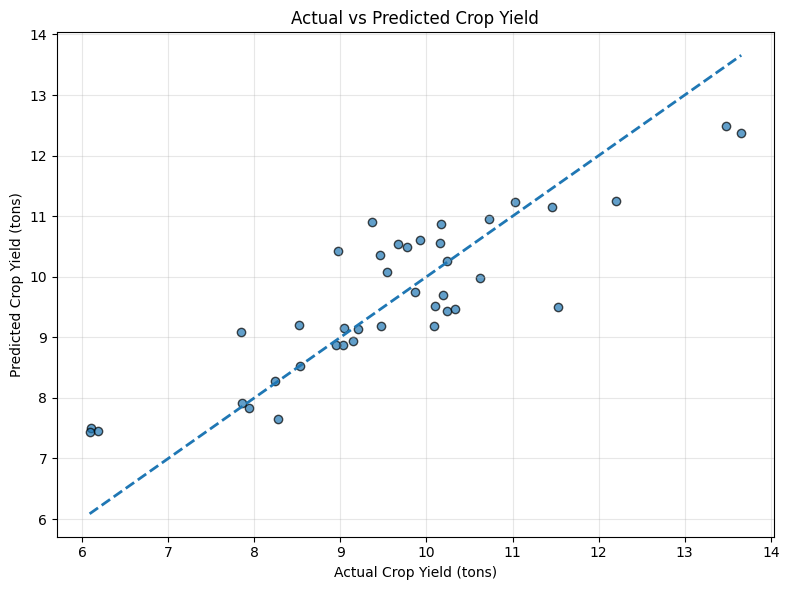

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    edgecolors="black"
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Crop Yield (tons)")
plt.ylabel("Predicted Crop Yield (tons)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd

real_df = pd.read_csv("/content/df_yield_merged.csv")

print("Dataset Shape:", real_df.shape)

print("\nColumn Names:")
print(real_df.columns.tolist())

print("\nFirst 5 Rows:")
display(real_df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/df_yield_merged.csv'

In [ ]:
/df_yield_merged.csv

NameError: name 'df_yield_merged' is not defined

In [ ]:
import pandas as pd

real_df = pd.read_csv("/df_yield_merged.csv")

print("Dataset Shape:", real_df.shape)

print("\nColumn Names:")
print(real_df.columns.tolist())

print("\nFirst 5 Rows:")
display(real_df.head())

Dataset Shape: (25932, 7)

Column Names:
['area', 'year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'item', 'value_hg_ha']

First 5 Rows:


,area,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,item,value_hg_ha
0,Albania,1990,1485.0,121.0,16.37,Maize,36613
1,Albania,1990,1485.0,121.0,16.37,Potatoes,66667
2,Albania,1990,1485.0,121.0,16.37,"Rice, paddy",23333
3,Albania,1990,1485.0,121.0,16.37,Sorghum,12500
4,Albania,1990,1485.0,121.0,16.37,Soybeans,7000


In [ ]:
print(real_df.columns.tolist())

['area', 'year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'item', 'value_hg_ha']


In [ ]:
print("Dataset Information:")
real_df.info()

print("\nMissing Values:")
print(real_df.isnull().sum())

print("\nDuplicate Rows:")
print(real_df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   area                           25932 non-null  object 
 1   year                           25932 non-null  int64  
 2   average_rain_fall_mm_per_year  25932 non-null  float64
 3   pesticides_tonnes              25932 non-null  float64
 4   avg_temp                       25932 non-null  float64
 5   item                           25932 non-null  object 
 6   value_hg_ha                    25932 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB

Missing Values:
area                             0
year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
item                             0
value_hg_ha                      0
dtype: 

In [ ]:
print("Missing values in each column:")
print(real_df.isnull().sum())

print("\nTotal missing values:")
print(real_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(real_df.duplicated().sum())

Missing values in each column:
area                             0
year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
item                             0
value_hg_ha                      0
dtype: int64

Total missing values:
0

Duplicate rows:
0


In [ ]:
X_real = real_df[
    [
        "area",
        "year",
        "average_rain_fall_mm_per_year",
        "pesticides_tonnes",
        "avg_temp",
        "item"
    ]
]

y_real = real_df["value_hg_ha"]

print("Features:")
display(X_real.head())

print("\nTarget:")
display(y_real.head())

print("\nFeature Shape:", X_real.shape)
print("Target Shape:", y_real.shape)

Features:


,area,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,item
0,Albania,1990,1485.0,121.0,16.37,Maize
1,Albania,1990,1485.0,121.0,16.37,Potatoes
2,Albania,1990,1485.0,121.0,16.37,"Rice, paddy"
3,Albania,1990,1485.0,121.0,16.37,Sorghum
4,Albania,1990,1485.0,121.0,16.37,Soybeans



Target:


,value_hg_ha
0,36613
1,66667
2,23333
3,12500
4,7000



Feature Shape: (25932, 6)
Target Shape: (25932,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["area", "item"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X_real)

print("Original Feature Shape:", X_real.shape)
print("Encoded Feature Shape:", X_encoded.shape)

Original Feature Shape: (25932, 6)
Encoded Feature Shape: (25932, 115)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_encoded,
    y_real,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_real.shape[0])
print("Testing samples:", X_test_real.shape[0])

Training samples: 20745
Testing samples: 5187


In [ ]:
from sklearn.ensemble import RandomForestRegressor

real_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

real_model.fit(X_train_real, y_train_real)

print("Random Forest model trained successfully! 🌾🤖")

Random Forest model trained successfully! 🌾🤖


In [ ]:
y_pred_real = real_model.predict(X_test_real)

print("Prediction completed successfully! 🌾")
print("\nFirst 10 Actual Values:")
print(y_test_real.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_real[:10])

Prediction completed successfully! 🌾

First 10 Actual Values:
[155782  15787  86899  30774  28085 216325 153997  16223  49591 367969]

First 10 Predicted Values:
[122744.98  15756.18  82575.64  22206.68  28079.36 212906.17 161732.48
  14757.74  64999.88 221689.84]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_real = mean_absolute_error(y_test_real, y_pred_real)
mse_real = mean_squared_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)
r2_real = r2_score(y_test_real, y_pred_real)

print("Real Dataset Model Evaluation")
print("--------------------------------")
print("MAE :", mae_real)
print("MSE :", mse_real)
print("RMSE:", rmse_real)
print("R² Score:", r2_real)

Real Dataset Model Evaluation
--------------------------------
MAE : 4078.327763639869
MSE : 120012853.07454577
RMSE: 10955.037794300199
R² Score: 0.9838661591727191


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.5,
    edgecolors="black"
)

min_value = min(y_test_real.min(), y_pred_real.min())
max_value = max(y_test_real.max(), y_pred_real.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Crop Yield (hg/ha)")
plt.ylabel("Predicted Crop Yield (hg/ha)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

NameError: name 'y_test_real' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_encoded,
    y_real,
    test_size=0.2,
    random_state=42
)

y_pred_real = real_model.predict(X_test_real)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.5,
    edgecolors="black"
)

min_value = min(y_test_real.min(), y_pred_real.min())
max_value = max(y_test_real.max(), y_pred_real.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Crop Yield (hg/ha)")
plt.ylabel("Predicted Crop Yield (hg/ha)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

NameError: name 'X_encoded' is not defined

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Features and target
X_real = real_df[
    [
        "area",
        "year",
        "average_rain_fall_mm_per_year",
        "pesticides_tonnes",
        "avg_temp",
        "item"
    ]
]

y_real = real_df["value_hg_ha"]

# Encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["area", "item"]
        )
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X_real)

# Train-test split
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_encoded,
    y_real,
    test_size=0.2,
    random_state=42
)

# Prediction
y_pred_real = real_model.predict(X_test_real)

# Actual vs Predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.5,
    edgecolors="black"
)

min_value = min(y_test_real.min(), y_pred_real.min())
max_value = max(y_test_real.max(), y_pred_real.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Crop Yield (hg/ha)")
plt.ylabel("Predicted Crop Yield (hg/ha)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'real_df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [ ]:
real_df = pd.read_csv("/df_yield_merged.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", real_df.shape)
print("Columns:", real_df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/df_yield_merged.csv'

In [1]:
real_df = pd.read_csv("/content/df_yield_merged.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", real_df.shape)
print("Columns:", real_df.columns.tolist())

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

print("Pandas imported successfully! ✅")

Pandas imported successfully! ✅


In [3]:
real_df = pd.read_csv("/content/df_yield_merged.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", real_df.shape)
print("Columns:", real_df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/df_yield_merged.csv'

In [4]:
real_df = pd.read_csv("/content/df_yield_merged.csv")

print("Dataset loaded successfully! ✅")
print("Shape:", real_df.shape)
print("Columns:", real_df.columns.tolist())

Dataset loaded successfully! ✅
Shape: (25932, 7)
Columns: ['area', 'year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'item', 'value_hg_ha']


In [5]:
X_real = real_df[
    [
        "area",
        "year",
        "average_rain_fall_mm_per_year",
        "pesticides_tonnes",
        "avg_temp",
        "item"
    ]
]

y_real = real_df["value_hg_ha"]

print("Features shape:", X_real.shape)
print("Target shape:", y_real.shape)

Features shape: (25932, 6)
Target shape: (25932,)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            ["area", "item"]
        )
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X_real)

print("Original features:", X_real.shape)
print("Encoded features:", X_encoded.shape)

Original features: (25932, 6)
Encoded features: (25932, 115)


In [7]:
from sklearn.model_selection import train_test_split

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_encoded,
    y_real,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_real.shape[0])
print("Testing samples:", X_test_real.shape[0])

Training samples: 20745
Testing samples: 5187


In [9]:
from sklearn.ensemble import RandomForestRegressor

real_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

real_model.fit(X_train_real, y_train_real)

print("Random Forest model trained successfully! 🌾🤖")

Random Forest model trained successfully! 🌾🤖


In [10]:
y_pred_real = real_model.predict(X_test_real)

print("Prediction completed successfully! 🌾")

print("\nFirst 10 Actual Values:")
print(y_test_real.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred_real[:10])

Prediction completed successfully! 🌾

First 10 Actual Values:
[155782  15787  86899  30774  28085 216325 153997  16223  49591 367969]

First 10 Predicted Values:
[122744.98  15756.18  82575.64  22206.68  28079.36 212906.17 161732.48
  14757.74  64999.88 221689.84]


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_real = mean_absolute_error(y_test_real, y_pred_real)
mse_real = mean_squared_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mse_real)
r2_real = r2_score(y_test_real, y_pred_real)

print("Real Dataset Model Evaluation")
print("--------------------------------")
print("MAE :", mae_real)
print("MSE :", mse_real)
print("RMSE:", rmse_real)
print("R² Score:", r2_real)

Real Dataset Model Evaluation
--------------------------------
MAE : 4078.327763639869
MSE : 120012853.07454577
RMSE: 10955.037794300199
R² Score: 0.9838661591727191


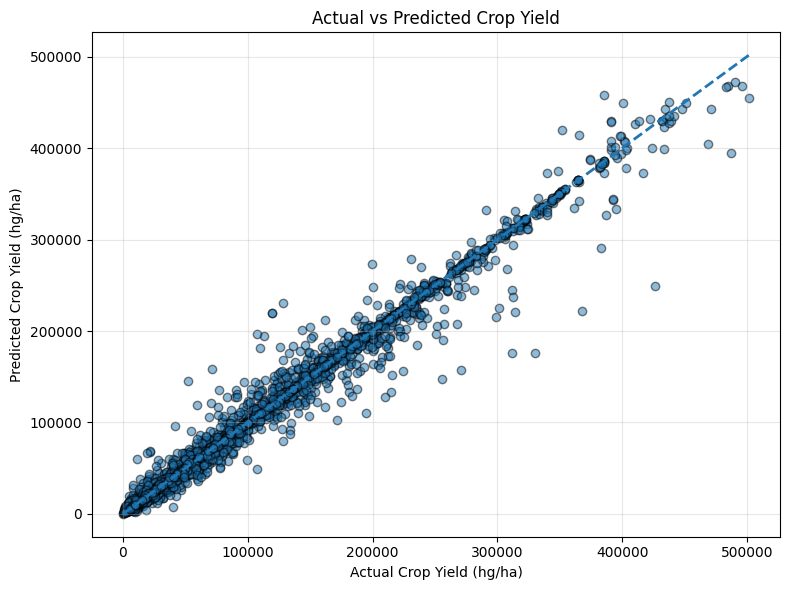

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_real,
    y_pred_real,
    alpha=0.5,
    edgecolors="black"
)

min_value = min(y_test_real.min(), y_pred_real.min())
max_value = max(y_test_real.max(), y_pred_real.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Crop Yield (hg/ha)")
plt.ylabel("Predicted Crop Yield (hg/ha)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Top 15 Important Features:


,Feature,Importance
104,categorical__item_Potatoes,0.373076
101,categorical__item_Cassava,0.092828
108,categorical__item_Sweet potatoes,0.082778
113,remainder__pesticides_tonnes,0.075021
42,categorical__area_India,0.056581
114,remainder__avg_temp,0.043437
112,remainder__average_rain_fall_mm_per_year,0.041901
111,remainder__year,0.034185
110,categorical__item_Yams,0.024645
103,categorical__item_Plantains and others,0.016598


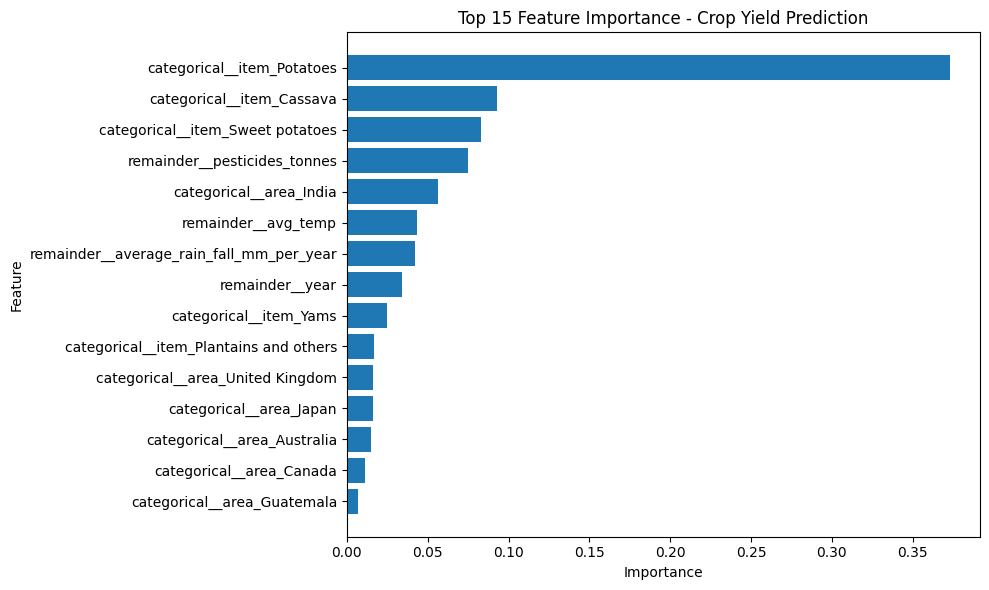

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importance = real_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(feature_importance.head(15))

# Plot top 15
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Crop Yield Prediction")

plt.tight_layout()
plt.show()

In [14]:
import joblib

joblib.dump(
    real_model,
    "crop_yield_real_random_forest.pkl"
)

print("Real Crop Yield model saved successfully! ✅")

Real Crop Yield model saved successfully! ✅


In [15]:
joblib.dump(
    preprocessor,
    "crop_yield_preprocessor.pkl"
)

print("Preprocessor saved successfully! ✅")

Preprocessor saved successfully! ✅


In [16]:
import joblib

joblib.dump(
    real_model,
    "/content/crop_yield_real_random_forest.pkl"
)

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [17]:
joblib.dump(
    preprocessor,
    "/content/crop_yield_preprocessor.pkl"
)

print("Preprocessor saved successfully! ✅")

Preprocessor saved successfully! ✅


In [18]:
# Example new crop input

new_crop = pd.DataFrame({
    "area": ["India"],
    "year": [2020],
    "average_rain_fall_mm_per_year": [1083],
    "pesticides_tonnes": [50000],
    "avg_temp": [25],
    "item": ["Maize"]
})

# Preprocess the new input
new_crop_encoded = preprocessor.transform(new_crop)

# Predict yield
predicted_yield = real_model.predict(new_crop_encoded)

print("🌾 Crop Yield Prediction")
print("-------------------------")
print("Area:", new_crop["area"].iloc[0])
print("Year:", new_crop["year"].iloc[0])
print("Crop:", new_crop["item"].iloc[0])
print("Rainfall:", new_crop["average_rain_fall_mm_per_year"].iloc[0], "mm/year")
print("Temperature:", new_crop["avg_temp"].iloc[0], "°C")
print("Pesticides:", new_crop["pesticides_tonnes"].iloc[0], "tonnes")
print()
print("Predicted Yield:", round(predicted_yield[0], 2), "hg/ha")

🌾 Crop Yield Prediction
-------------------------
Area: India
Year: 2020
Crop: Maize
Rainfall: 1083 mm/year
Temperature: 25 °C
Pesticides: 50000 tonnes

Predicted Yield: 26352.29 hg/ha
